<a href="https://colab.research.google.com/github/MadonnaOsama/Differential-Gene-Expression-Analysis/blob/main/Copy_of_madonna%E2%80%99s_graduation_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

# Differential Expression Analysis (DEA) Project - Workflow


# 1. Import libraries
#    - pandas, numpy, matplotlib, seaborn, scipy, statsmodels, biopython

# 2. Load data
#    - Expression matrix (rows = genes/probes, columns = samples)
#    - Metadata (sample IDs, conditions)
#    - match sample name between metadata and expression matrix

# 3. Preprocessing
#     - Basic QC: look at distributions
#      see if data is raw counts, log-transformed, or already normalized----> Summary statistics----> .describe()
#                                                                                       If values range from 0–1000s → raw counts
#                                                                                       If values range from ~0–15 → already log-transformed.
#                                                                       ----> distributions----> Boxplot or density plot,
#                                                                                             check if samples have similar distributions
#    - Handle missing values (drop or impute)
#    - Log2 transform (if data not already log-transformed)
#    - Normalize expression values (quantile normalization)
#    - Filter out low-expression or low-variance genes

# 4. Exploratory Data Analysis (EDA)
#    - Heatmap of top variable genes → check overall structure

# 5. Define groups for comparison
#    - Select two (or more) conditions from metadata
#    - Subset expression matrix based on these groups

# 6. Differential Expression Testing
#    - For each gene:
#         - Compute fold change (log2FC) between groups
#         - Perform statistical test (t-test)
#    - Collect results: log2FC, p-value for each gene

# 7. Multiple Testing Correction
#    - Adjust p-values using FDR (Benjamini-Hochberg)
#    - Mark significant genes (e.g., adj_p < 0.05 and |log2FC| > 1)

# 8. Results Table
#    - Save DataFrame with gene, log2FC, p-value, adj_p-value,-log10p-val
#    - Export as CSV for later use

# 9. Visualization
#    - Volcano plot → log2FC vs -log10(p-value)
#    - Heatmap → expression of top significant genes


# 10. Annotation (using GEO file)
#    - Use the annotation file to add gene symbols/descriptions



In [ ]:
# step1: import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests

In [ ]:
#step2: load data
expression = pd.read_csv("/content/expession breast cancer.txt",sep="\t", comment="!", index_col=0)
print("expression shape:", expression.shape)
expression.head()


expression shape: (1455, 155)


,GSM1116084,GSM1116085,GSM1116086,GSM1116087,GSM1116088,GSM1116089,GSM1116090,GSM1116091,GSM1116092,GSM1116093,...,GSM1116229,GSM1116230,GSM1116231,GSM1116232,GSM1116233,GSM1116234,GSM1116235,GSM1116236,GSM1116237,GSM1116238
ID_REF,,,,,,,,,,,,,,,,,,,,,
1007_s_at,9.47065,9.67440,10.20800,10.11420,11.16360,10.00690,9.53932,9.00187,6.54074,10.35510,...,9.96811,10.10680,10.03290,9.84599,10.75850,10.55470,9.45290,10.80010,10.04640,11.42010
1053_at,8.36311,8.72194,7.78601,9.44537,7.71242,7.84274,7.56238,8.01540,9.37874,9.45426,...,7.25745,7.54377,7.41607,5.83454,8.83376,6.88277,6.83700,7.29371,7.71122,7.63877
117_at,5.95426,7.02523,6.39671,4.56023,5.29008,6.21590,6.42180,6.23554,5.43541,3.85652,...,8.35832,6.98743,4.50611,4.78051,4.55847,4.14597,6.10766,5.41169,4.57742,4.67159
1294_at,6.02119,7.24581,6.85310,5.42786,7.51120,5.79719,7.36700,7.17268,7.72472,4.79560,...,7.18591,7.74070,7.44448,7.03001,6.87039,6.37882,6.99674,8.37598,6.56774,7.40374
1316_at,3.22997,3.29352,3.26204,3.34766,3.59086,3.40108,3.27663,3.14212,3.28420,3.27900,...,3.50312,3.57309,3.31572,3.70289,4.82208,3.55309,3.23899,3.84879,3.28091,3.24882


In [ ]:
metadata = pd.read_csv("/content/metadata2.CSV")
print("metadata shape:", metadata.shape)
metadata.head()


metadata shape: (155, 2)


,SampleID,Condition
0,GSM1116084,Basal
1,GSM1116085,Basal
2,GSM1116086,Basal
3,GSM1116087,Basal
4,GSM1116088,Her2


In [ ]:
meta_samples = metadata['SampleID'].astype(str).tolist()
expr_samples = expression.columns.astype(str).tolist()

missing_in_expr = [s for s in meta_samples if s not in expr_samples]
extra_in_expr   = [s for s in expr_samples if s not in meta_samples]

print("Samples in metadata not in expression:", missing_in_expr[:10])
print("Extra samples in expression not in metadata:", extra_in_expr[:10])

common_samples = expression.columns.intersection(metadata['SampleID'])

expression = expression[common_samples]

print("Final number of common samples:", len(common_samples))



Samples in metadata not in expression: []
Extra samples in expression not in metadata: []
Final number of common samples: 155


In [ ]:
# step3: preprocessing
# see if data is raw counts, log-transformed, or already normalized----> a) Summary statistics
import seaborn as sns
sns.set(style="whitegrid")
expression.describe().T[['min','25%','50%','75%','max']].head()         # note:values range from ~0–15 → already log-transformed

,min,25%,50%,75%,max
GSM1116084,0.387270,3.457960,4.85855,6.895590,15.9697
GSM1116085,0.369878,3.512855,5.00519,6.988230,15.9785
GSM1116086,0.104880,3.427670,4.70495,6.764770,15.9993
GSM1116087,0.055358,3.555735,4.83478,6.828000,15.7994
GSM1116088,1.171060,3.545095,4.82280,6.834695,15.6341


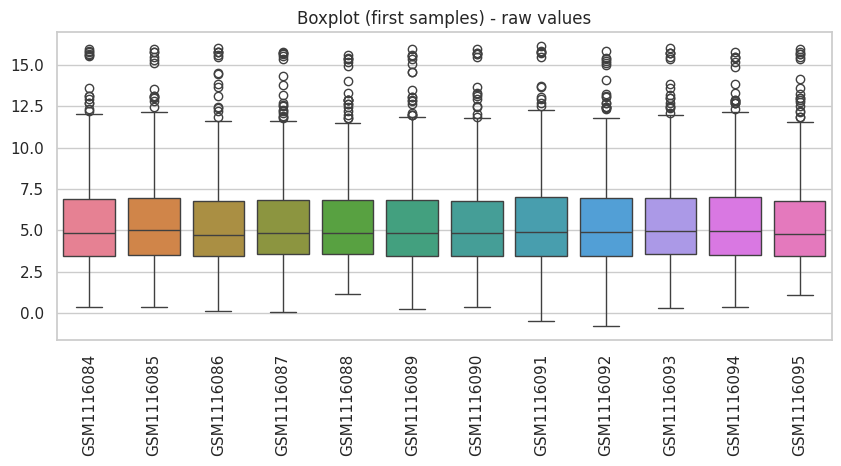

In [ ]:
# ----> b) distributions
# Boxplot or density plot,check if samples have similar distributions
plt.figure(figsize=(10,4))
sns.boxplot(data=expression.iloc[:,:12])
plt.xticks(rotation=90)
plt.title("Boxplot (first samples) - raw values")      #the shapes and ranges of the boxes across samples are quite similar → most samples are on the same scale.
                                                       #Median expression is around ~5 for all samples → no huge bias.
                                                       #need normalization (boxplots dont line up perfectly)
plt.show()

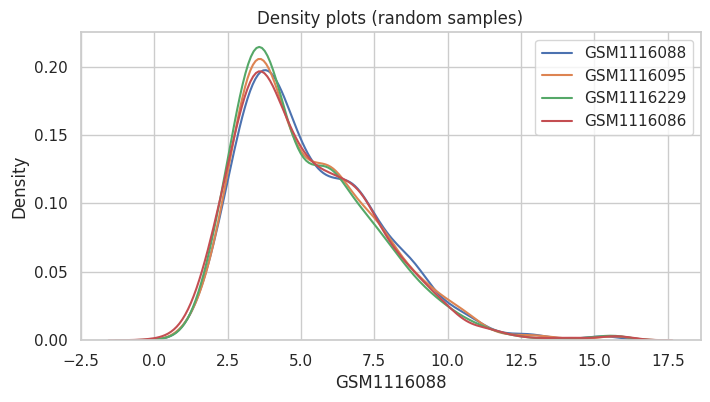

In [ ]:
plt.figure(figsize=(8,4))
for c in np.random.choice(expression.columns, size=4, replace=False):
    sns.kdeplot(expression[c],label=c)
plt.legend()
plt.title("Density plots (random samples)")
plt.show()                                                  #All 4 samples have very similar distributions.
                                                            #The peak is around 4–6 → most genes in all samples have expression values in this range.
                                                            #he tails extend to ~15–17, which indicates a small number of highly expressed genes.
                                                            # normalization still needed(density plot should overlap excatly)

In [ ]:
if expression.values.max() > 100:
    expression = np.log2(expression + 1.0)
    print("Applied log2(x+1) transform")
else:
    print("No log transform applied (values appear small/log-scale)")


No log transform applied (values appear small/log-scale)


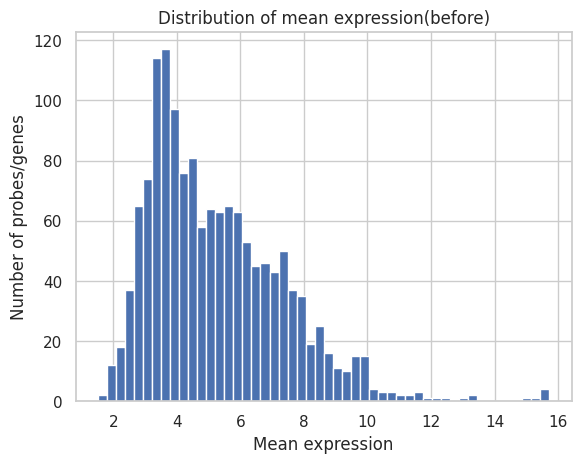

In [ ]:
# Filter out low-expression genes
mean_values = expression.mean(axis=1)
plt.hist(mean_values, bins=50)
plt.xlabel("Mean expression")
plt.ylabel("Number of probes/genes")
plt.title("Distribution of mean expression(before)")
plt.show()                               # Most of the probes have mean expression between 3–6.
                                         # This is a typical pattern for microarray log2-transformed data.
                                         #A reasonable filter cutoff for mean expression would be around 4–5.
                                         #Below 4, many probes are likely background noise


In [ ]:
expression = expression.loc[expression.mean(axis=1) > 5]
expression.shape




(686, 155)

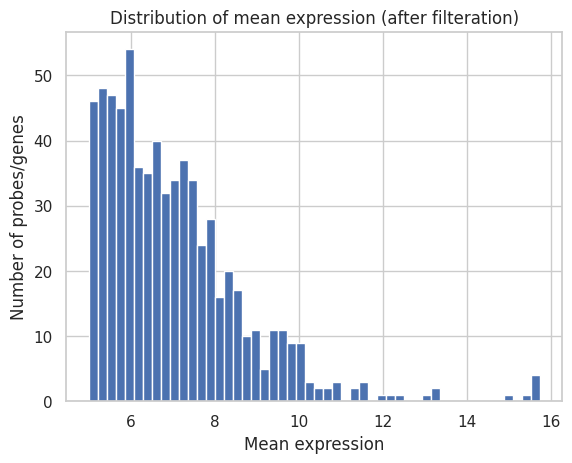

In [ ]:
mean_values = expression.mean(axis=1)
plt.hist(mean_values, bins=50)
plt.xlabel("Mean expression")
plt.ylabel("Number of probes/genes")
plt.title("Distribution of mean expression (after filteration)")
plt.show()

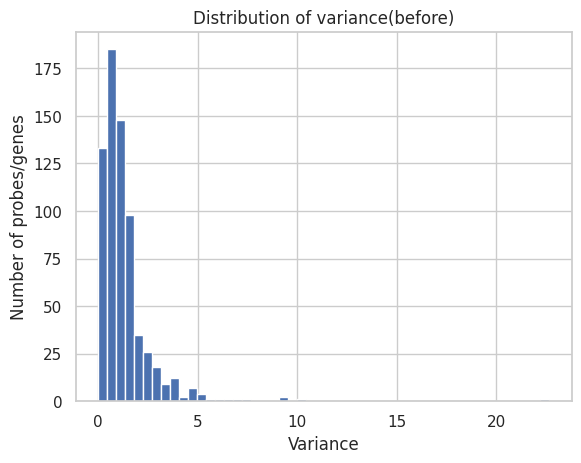

In [ ]:
# Filter out low-variance genes
var_values = expression.var(axis=1)
plt.hist(var_values, bins=50)
plt.xlabel("Variance")
plt.ylabel("Number of probes/genes")
plt.title("Distribution of variance(before)")
plt.show()                                     # Most probes have very low variance (0–1).
                                                #These genes don’t change much across samples.
                                                #They’re likely housekeeping genes (always on at the same level) or uninformative probes
                                                # so they will not distinguish coditions like normal vs cancer

In [ ]:
expression = expression.loc[var_values > 0.5]   # removing low variance probes
expression.shape


(536, 155)

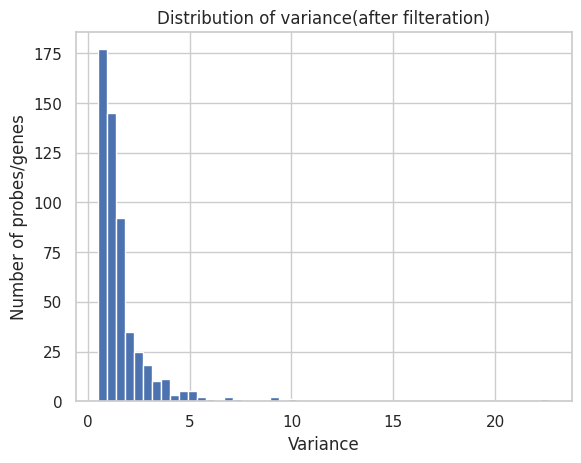

In [ ]:
var_values = expression.var(axis=1)
plt.hist(var_values, bins=50)
plt.xlabel("Variance")
plt.ylabel("Number of probes/genes")
plt.title("Distribution of variance(after filteration)")
plt.show()

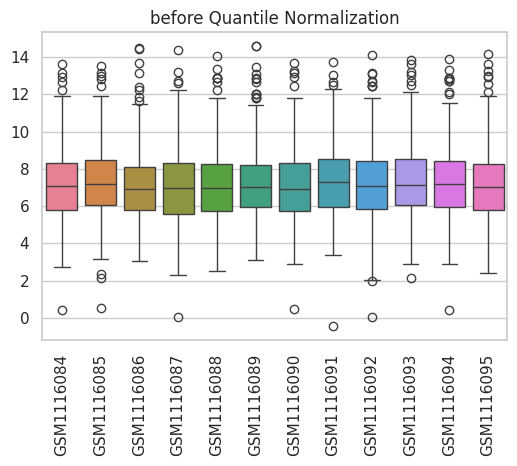

In [ ]:
# double check after filteration to make sure that data really need normalization
plt.figure(figsize=(6,4))
C = sns.boxplot(data=expression.iloc[:,:12])
plt.xticks(rotation=90)
plt.title("before Quantile Normalization")
plt.show()                                           # note: the medians and spreads differ noticeably between samples---> normalization needed

In [ ]:
# Quantile normalization
def quantile_normalize(df):
    arr = df.values.copy()                        # convert DataFrame to numpy array (numeric only) and make a copy
    sorted_idx = np.argsort(arr, axis=0)          # get indices that would sort each column (rank order per sample)
    sorted_vals = np.sort(arr, axis=0)            # sort values in each column (ascending order)

    mean_sorted = np.mean(sorted_vals, axis=1)     # calculate the mean across samples for each rank position(each column)
    res = np.zeros_like(arr)                       # create an empty array with the same shape to store normalized values
    for j in range(arr.shape[1]):
        res[sorted_idx[:, j], j] = mean_sorted     # assign the averaged rank values (mean_sorted) back to the original gene order
    return pd.DataFrame(res, index=df.index, columns=df.columns)   # return the normalized array as a DataFrame, keeping original row/column names

expr_qn = quantile_normalize(expression)

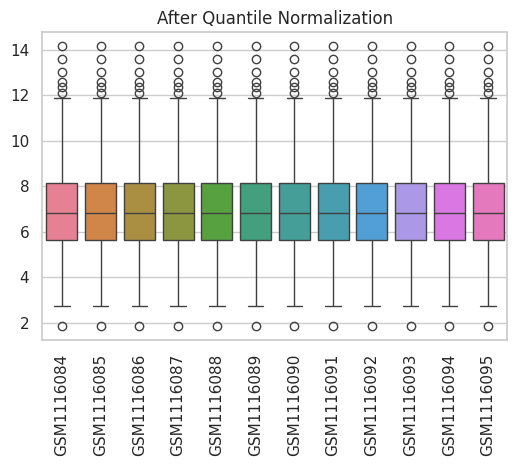

In [ ]:
plt.figure(figsize=(6,4))
C = sns.boxplot(data=expr_qn.iloc[:,:12])
plt.xticks(rotation=90)
plt.title("After Quantile Normalization")
plt.show()                                         # note: all boxplots become aligned (same median, same spread).

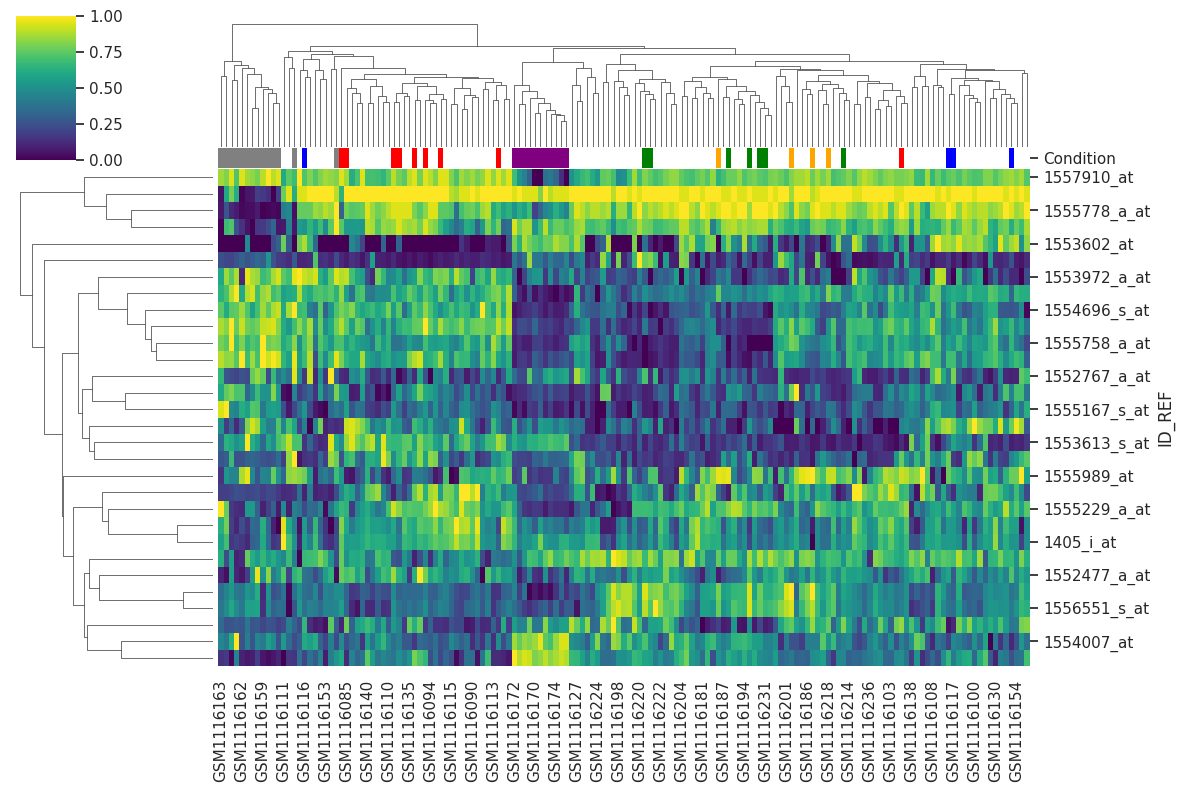

In [ ]:
# step 4: Exploratory Data Analysis (EDA
top_genes = expr_qn.var(axis=1).sort_values(ascending=False).head(30).index
expr_top = expr_qn.loc[top_genes]

#  Extract sample conditions from metadata
sample_conditions = metadata.set_index("SampleID")["Condition"]
sample_conditions = sample_conditions.reindex(expr_top.columns)  # align order


condition_colors = {
    "Basal": "red",
    "Her2": "blue",
    "Luminal A": "green",
    "Luminal B": "orange",
    "Normal": "purple",
    "CellLine": "gray"
}
col_colors = sample_conditions.map(condition_colors)

sns.clustermap(                                                                 #The result looked very crowded and noisy — no clear blocks or separation.
 expr_top,                                                                      #This is normal, because most genes are not differentially expressed
    cmap= "viridis",                                                            #(they look random, not useful for separating groups).
    metric="euclidean",                                                         #Conclusion at this step: Data quality looks okay,
    method="average",                                                           #but we cannot see group differences yet because too many irrelevant genes are included.
    standard_scale=0,
    col_colors=col_colors,
    figsize=(12, 8)
)

plt.show()


In [ ]:
print("Final expression shape:", expr_qn.shape)
expr_qn.to_csv("expression_processed.csv")
metadata.to_csv("metadata_aligned.csv", index=False)
print("Saved expression_processed.csv and metadata_aligned.csv")


Final expression shape: (536, 155)
Saved expression_processed.csv and metadata_aligned.csv


In [ ]:
import pandas as pd
expr_qn=pd.read_csv("/content/expression_processed.csv", index_col=0)
meta=pd.read_csv("/content/metadata_aligned.csv")
expr_qn.head()

,GSM1116084,GSM1116085,GSM1116086,GSM1116087,GSM1116088,GSM1116089,GSM1116090,GSM1116091,GSM1116092,GSM1116093,...,GSM1116229,GSM1116230,GSM1116231,GSM1116232,GSM1116233,GSM1116234,GSM1116235,GSM1116236,GSM1116237,GSM1116238
ID_REF,,,,,,,,,,,,,,,,,,,,,
1007_s_at,9.090356,9.433958,10.278662,9.947412,11.138494,9.855485,9.275059,8.663837,6.262110,9.975719,...,9.947412,10.810323,9.916379,9.484522,10.455638,10.278662,9.227918,10.674340,10.038309,11.673595
1053_at,8.188569,8.465195,7.813637,9.227918,7.567772,7.824265,7.359378,7.694721,9.108368,8.976892,...,7.350328,7.912551,7.494359,5.568678,8.821357,6.739203,6.713365,7.342129,7.616566,7.743617
117_at,5.723644,6.695040,6.262110,4.640266,5.209513,5.920945,6.296385,5.837177,5.209513,3.702977,...,8.465195,7.426808,4.262575,4.612233,4.360487,3.999687,5.938293,5.300843,4.380889,4.566590
1294_at,5.788072,6.934260,6.739203,5.537289,7.398937,5.505359,7.229785,6.713365,7.521110,4.612233,...,7.239743,8.141038,7.548988,6.703357,6.643296,6.279397,6.942301,8.385540,6.525942,7.445673
1405_i_at,10.877508,8.943382,9.410403,11.365519,8.606415,8.943382,10.959680,11.047305,8.804455,3.788493,...,8.358588,8.976892,7.408715,6.863213,8.836778,6.253211,9.366165,8.176516,8.037829,8.531766


In [ ]:
# step5: Define groups for comparison
subtypes = ["Basal", "Her2", "Luminal A", "Luminal B", "CellLine"]

samples_normal = meta[meta["Condition"] == "Normal"]["SampleID"]
expr_normal = expr_qn[samples_normal]

# step6. Differential Expression Testing
all_results = []

for subtype in subtypes:
    samples_sub = meta[meta["Condition"] == subtype]["SampleID"]
    expr_sub = expr_qn[samples_sub]

    mean_normal = expr_normal.mean(axis=1)
    mean_sub = expr_sub.mean(axis=1)
    log2FC = mean_sub - mean_normal

    pvals = []
    for gene in expr_qn.index:
        values_sub = expr_sub.loc[gene].values
        values_normal = expr_normal.loc[gene].values

        # Perform Welch's t-test (unequal variance)
        t_stat, p_val = stats.ttest_ind(values_sub, values_normal, equal_var=False)


        pvals.append(p_val)

    #Correct for multiple testing using FDR (Benjamini-Hochberg)
    reject, pvals_adj, _, _ = multipletests(pvals, method="fdr_bh")         #when doing many statistical tests(thousands of gene),some p_values will be small just by chance
                                                                            #so multipletests adjust p_values to control false positive results
    results = pd.DataFrame({
        "gene": expr_qn.index,
        "subtype": subtype,
        "log2FC": log2FC,
        "pvalue": pvals,
        "adj_pval": pvals_adj,
        "significant": reject
    })

    # transform p-values for plotting (volcano plots)
    results["neg_log10_pval"] = -np.log10(results["pvalue"] + 1e-300)

    all_results.append(results)

final_results = pd.concat(all_results, ignore_index=True)

final_results.head()


,gene,subtype,log2FC,pvalue,adj_pval,significant,neg_log10_pval
0,1007_s_at,Basal,-0.786134,2.268796e-03,0.005242,True,2.644205
1,1053_at,Basal,1.278634,4.174591e-03,0.008775,True,2.379386
2,117_at,Basal,0.993011,8.809834e-03,0.016865,True,2.055032
3,1294_at,Basal,-3.375536,8.728604e-08,0.000002,True,7.059055
4,1405_i_at,Basal,-0.039726,9.504346e-01,0.957581,False,0.022078


In [ ]:
#step8: Results Table
final_results.to_csv("differential_expression_results.csv", index=False)

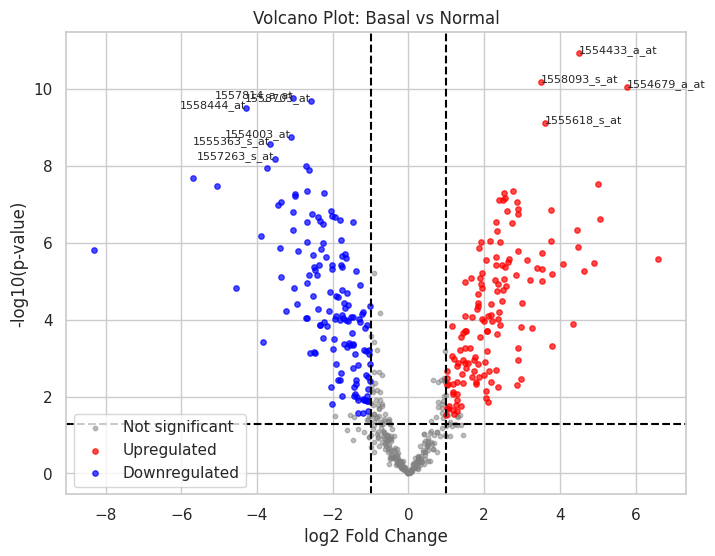

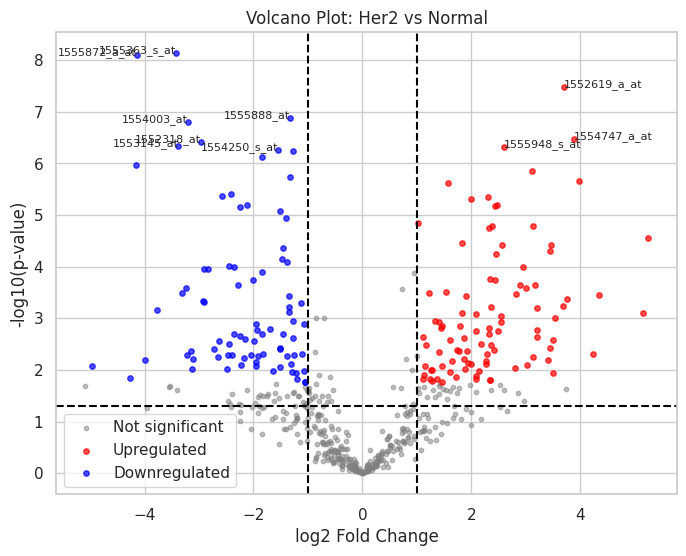

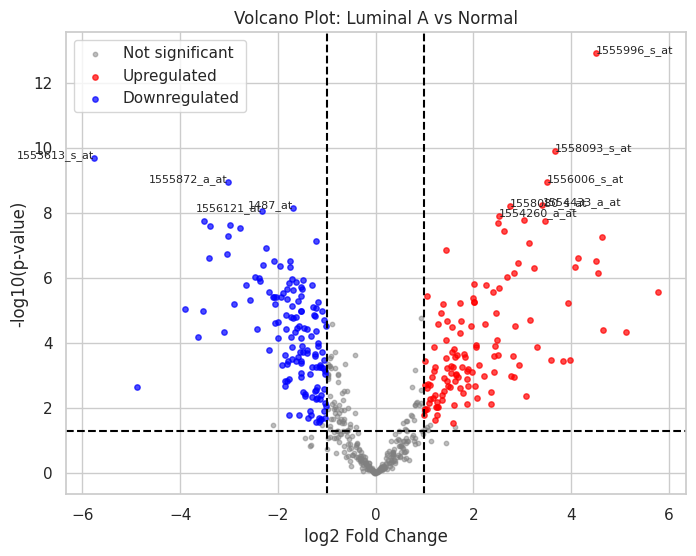

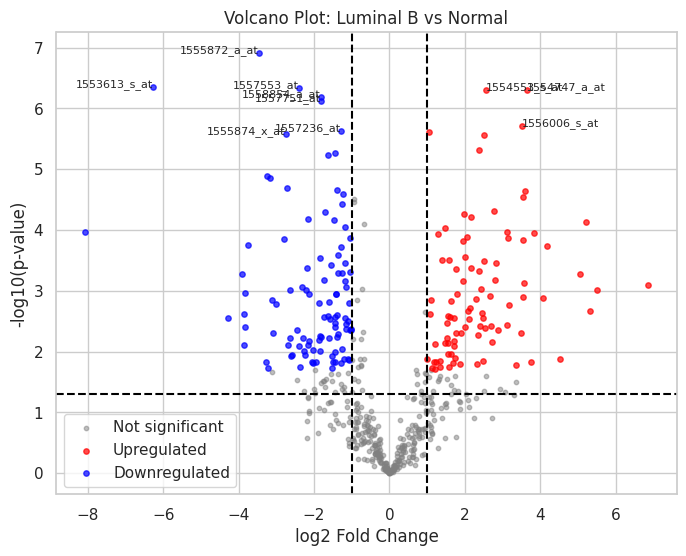

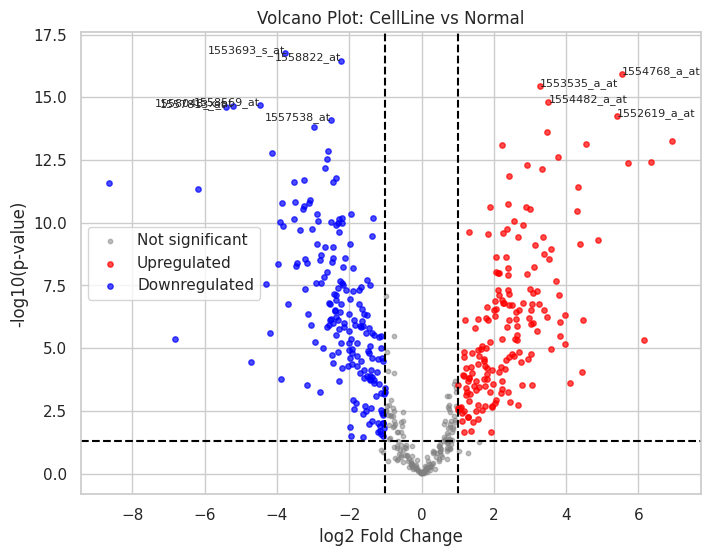

In [ ]:
#step9: visualization
subtypes = ["Basal", "Her2", "Luminal A", "Luminal B" ,"CellLine"]

for subtype in subtypes:
    sub_data = final_results[final_results["subtype"] == subtype]

    plt.figure(figsize=(8,6))
    sig = sub_data[(sub_data["adj_pval"] < 0.05) & (abs(sub_data["log2FC"]) > 1)]   #sig is a DataFrame containing only significant genes for each subtype
    up = sig[sig["log2FC"] > 0]
    down = sig[sig["log2FC"] < 0]
    non_sig = sub_data[~sub_data.index.isin(sig.index)]     # Non-significant genes (all genes not in 'sig')
                                                            # sub_data.index.isin(sig.index) → True for significant genes
                                                            # ~ inverts (so False for significant → True for non-significant)

    # Plot points
    plt.scatter(non_sig["log2FC"], non_sig["neg_log10_pval"], c="gray", alpha=0.5, s=10, label="Not significant")
    plt.scatter(up["log2FC"], up["neg_log10_pval"], c="red", alpha=0.7, s=15, label="Upregulated")
    plt.scatter(down["log2FC"], down["neg_log10_pval"], c="blue", alpha=0.7, s=15, label="Downregulated")

    # Threshold lines
    plt.axhline(-np.log10(0.05), color="black", linestyle="--")
    plt.axvline(1, color="black", linestyle="--")
    plt.axvline(-1, color="black", linestyle="--")



    top_genes = sig.sort_values("adj_pval").head(10)


    for _, row in top_genes.iterrows():

        plt.text(                       # Add the gene name as text on the volcano plot
        row["log2FC"],              # X position = log2 fold change
        row["neg_log10_pval"],      # Y position = -log10(p-value)
        row["gene"],                # The text label = gene name
        fontsize=8,
        ha='right' if row["log2FC"] < 0 else 'left')   # Align text to the right if log2FC < 0 (downregulated),
                                                       # otherwise align to the left (upregulated)


    # Labels and title
    plt.title(f"Volcano Plot: {subtype} vs Normal")
    plt.xlabel("log2 Fold Change")
    plt.ylabel("-log10(p-value)")
    plt.legend()

    # Save figure
    plt.savefig(f"volcano_{subtype}.png", dpi=300, bbox_inches="tight")
    plt.show()


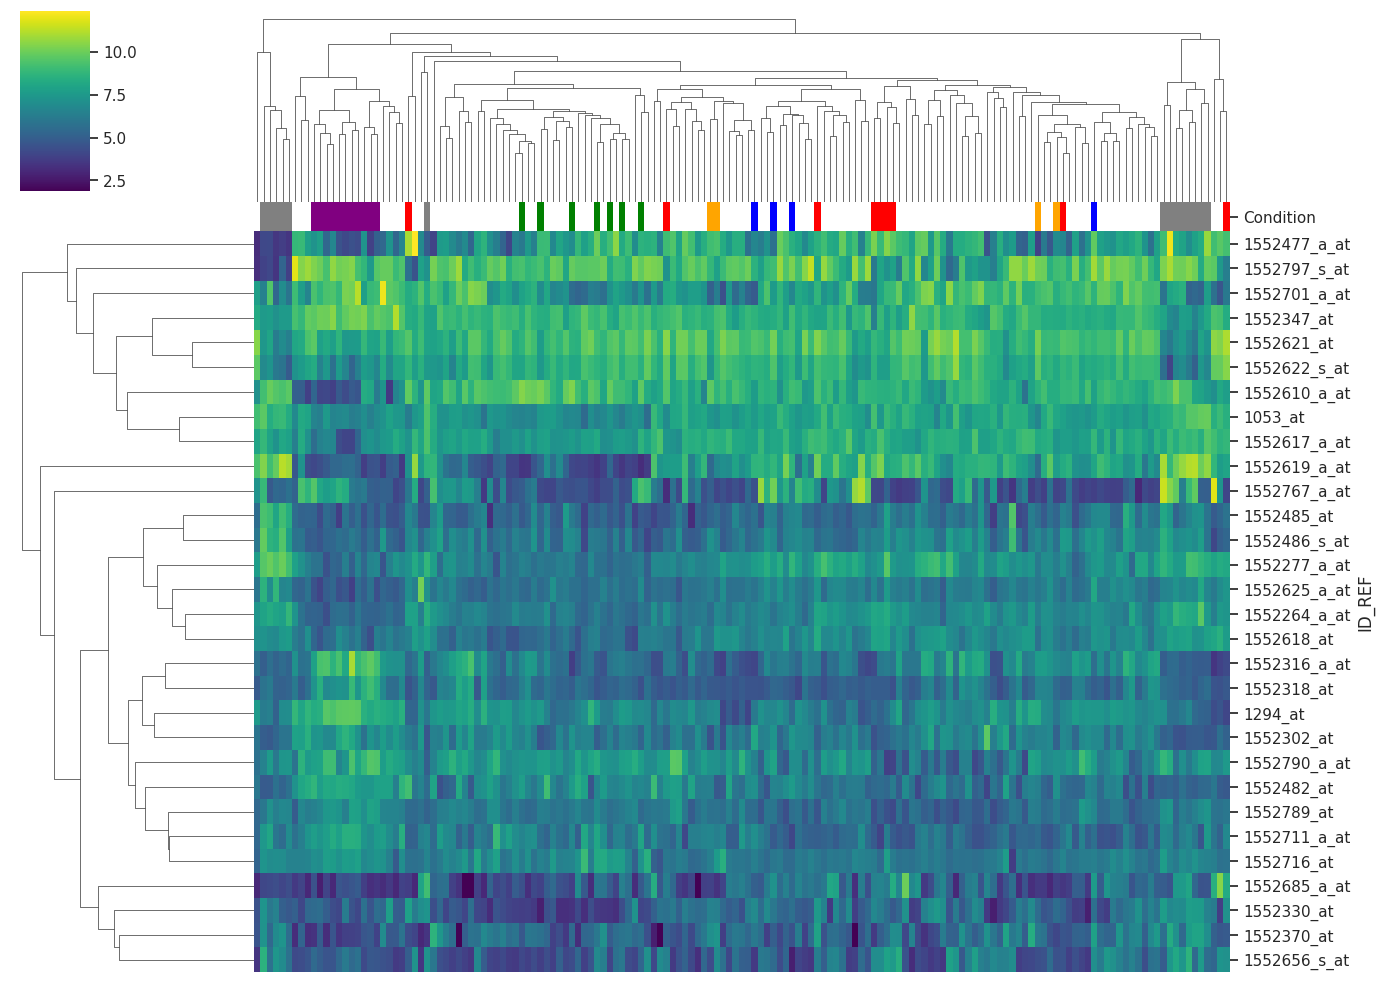

In [ ]:
sig_genes = final_results[(final_results["adj_pval"] < 0.05) &
                          (abs(final_results["log2FC"]) > 1)]["gene"].unique()

expr_sig = expr_qn.loc[sig_genes]

condition_colors = {
    "Basal": "red",
    "Her2": "blue",
    "Luminal A": "green",
    "Luminal B": "orange",
    "Normal": "purple",
    "CellLine": "gray"
}
sample_conditions = meta.set_index("SampleID")["Condition"]   # index by SampleID
sample_conditions = sample_conditions.reindex(expr_sig.columns)  # reorder to match columns
col_colors = sample_conditions.map(condition_colors)

sns.clustermap(expr_sig.head(30),
               cmap="viridis",
               col_colors=col_colors,
               figsize=(14, 10),
               xticklabels=False,
               yticklabels=True)

plt.show()
                             #After filtering to the top 30 differentially expressed genes, clearer clustering emerged.
                             #Specific genes consistently showed higher expression in one condition and lower in another,
                             #indicating their role in separating biological groups
                             #These genes are candidates for further investigation as biomarkers or drivers of the phenotype


In [ ]:
annot_file=pd.read_csv("/content/GPL570.annot", sep="\t",skiprows=27 ,low_memory=False)  #This uses more memory, but the column types are more accurate

annot_file = annot_file[["ID", "Gene symbol", "Gene title"]].rename(
    columns={"ID": "gene", "Gene Symbol": "gene_symbol", "Gene title": "description"}
)

annot_file.head()

,gene,Gene symbol,description
0,1007_s_at,MIR4640///DDR1,microRNA 4640///discoidin domain receptor tyro...
1,1053_at,RFC2,replication factor C subunit 2
2,117_at,HSPA6,heat shock protein family A (Hsp70) member 6
3,121_at,PAX8,paired box 8
4,1255_g_at,GUCA1A,guanylate cyclase activator 1A


In [ ]:
#step10: annotation
final_annotated = final_results.merge(annot_file, on="gene", how="left")   # type of join
final_annotated.head()


,gene,subtype,log2FC,pvalue,adj_pval,significant,neg_log10_pval,Gene symbol,description
0,1007_s_at,Basal,-0.786134,2.268796e-03,0.005242,True,2.644205,MIR4640///DDR1,microRNA 4640///discoidin domain receptor tyro...
1,1053_at,Basal,1.278634,4.174591e-03,0.008775,True,2.379386,RFC2,replication factor C subunit 2
2,117_at,Basal,0.993011,8.809834e-03,0.016865,True,2.055032,HSPA6,heat shock protein family A (Hsp70) member 6
3,1294_at,Basal,-3.375536,8.728604e-08,0.000002,True,7.059055,MIR5193///UBA7,microRNA 5193///ubiquitin like modifier activa...
4,1405_i_at,Basal,-0.039726,9.504346e-01,0.957581,False,0.022078,CCL5,C-C motif chemokine ligand 5
